## 0. Importar librerías
Todo lo que necesitamos en un solo lugar.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Para que los gráficos salgan bonitos
plt.style.use('seaborn-v0_8-whitegrid')
print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 1. Cargar el dataset
El archivo usa `|` como separador (no coma), así que se lo indicamos a pandas.

In [8]:
df = pd.read_csv(
    r"D:\The bridge\DS-Online-Hugo-Sanz\04_Machine_Learning\Sprint_10\Unidad_01_ML_Supervisado_Regresion_Lineal_Regularizacion\03_Practica_Obligatoria\data\hard_to_find\obligatoria_hard.csv",
    sep="|"
)

print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

print(f'Filas: {df.shape[0]}, Columnas: {df.shape[1]}')
df.head()

Filas: 506, Columnas: 13
Filas: 506, Columnas: 13


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [9]:
# Verificar que no hay nulos (el enunciado dice que está limpio)
print('Valores nulos por columna:')
print(df.isnull().sum())
print('\n✅ Sin nulos, podemos continuar')

Valores nulos por columna:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
LSTAT      0
MEDV       0
dtype: int64

✅ Sin nulos, podemos continuar


## 2. Analizar el target: MEDV
**MEDV** es el precio mediano de las casas en miles de dólares — esa es nuestra variable objetivo.

Para que la regresión lineal funcione bien, el target debería tener una distribución **aproximadamente normal**.
Vamos a verlo gráficamente.

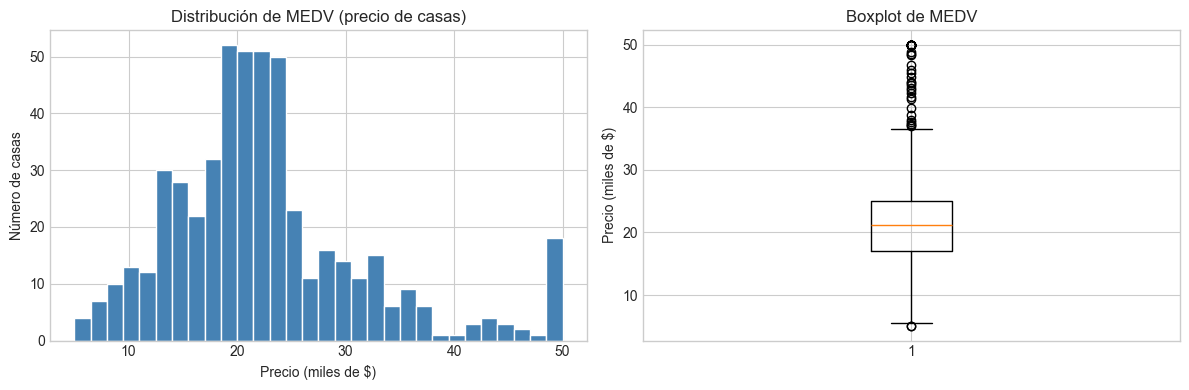

Media: 22.5k$
Mediana: 21.2k$
Rango: 5.0k$ - 50.0k$


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(df['MEDV'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de MEDV (precio de casas)')
axes[0].set_xlabel('Precio (miles de $)')
axes[0].set_ylabel('Número de casas')

# Boxplot
axes[1].boxplot(df['MEDV'], vert=True)
axes[1].set_title('Boxplot de MEDV')
axes[1].set_ylabel('Precio (miles de $)')

plt.tight_layout()
plt.show()

print(f'Media: {df["MEDV"].mean():.1f}k$')
print(f'Mediana: {df["MEDV"].median():.1f}k$')
print(f'Rango: {df["MEDV"].min():.1f}k$ - {df["MEDV"].max():.1f}k$')

**Conclusión:** La distribución es bastante simétrica y continua. 
Hay algunos valores altos (casas caras), pero en general la regresión lineal es apropiada para este problema.


## 3. Dividir en Train y Test
Separamos el 20% de los datos para test. Así podremos evaluar el modelo con datos que **nunca ha visto**.

In [11]:
X = df.drop('MEDV', axis=1)  # todas las columnas menos el precio
y = df['MEDV']                # solo el precio

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')

Train: 404 muestras
Test:  102 muestras


## 4. Mini-EDA: ¿Qué variables importan más?
Vamos a calcular la **correlación** de cada variable con MEDV.
Correlación alta (positiva o negativa) = la variable es más útil para predecir el precio.

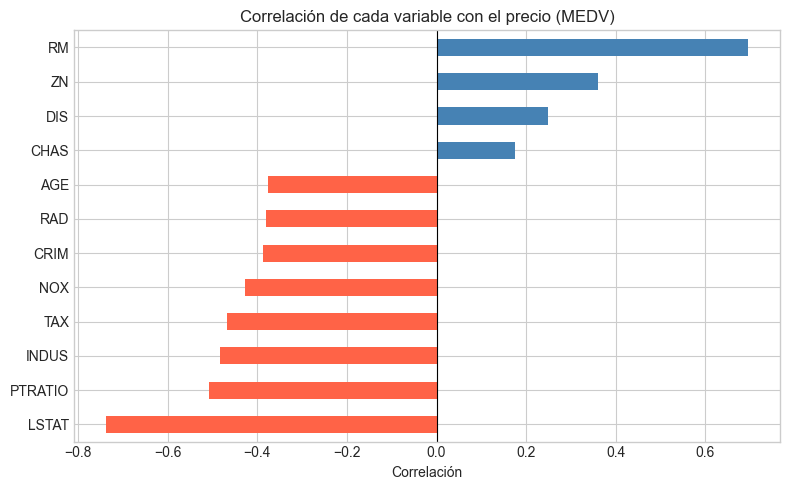

Las 3 variables más relacionadas con el precio:
LSTAT      0.737663
RM         0.695360
PTRATIO    0.507787
Name: MEDV, dtype: float64


In [12]:
# Correlaciones con el target
correlaciones = df.corr()['MEDV'].drop('MEDV').sort_values()

plt.figure(figsize=(8, 5))
correlaciones.plot(kind='barh', color=['tomato' if c < 0 else 'steelblue' for c in correlaciones])
plt.title('Correlación de cada variable con el precio (MEDV)')
plt.xlabel('Correlación')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Las 3 variables más relacionadas con el precio:')
print(correlaciones.abs().sort_values(ascending=False).head(3))

**Interpretación:**
- **LSTAT** (% población pobre): correlación muy negativa → más pobreza = precio más bajo ✅
- **RM** (número de habitaciones): correlación positiva → más habitaciones = precio más alto ✅
- Usaremos **todas las variables** porque incluso las menos correlacionadas aportan algo al modelo.


## 5. Escalar las variables
Las variables tienen rangos muy distintos (CRIM va de 0 a 89, ZN de 0 a 100...).
Con `StandardScaler` las ponemos todas en la misma escala → el modelo funciona mejor,
y la regularización (Ridge, Lasso) funciona correctamente.

In [13]:
scaler = StandardScaler()

# fit_transform en train: aprende la media y desviación, y transforma
X_train_scaled = scaler.fit_transform(X_train)

# Solo transform en test: aplica lo que aprendió en train
X_test_scaled = scaler.transform(X_test)

print('✅ Variables escaladas')
print(f'Media tras escalar (train): {X_train_scaled.mean():.4f}')  # debe ser ~0
print(f'Desviación estándar (train): {X_train_scaled.std():.4f}')  # debe ser ~1

✅ Variables escaladas
Media tras escalar (train): -0.0000
Desviación estándar (train): 1.0000


## 6. Modelo de Regresión Lineal
Entrenamos el modelo más básico para tener una línea de referencia.

✅ Modelo entrenado


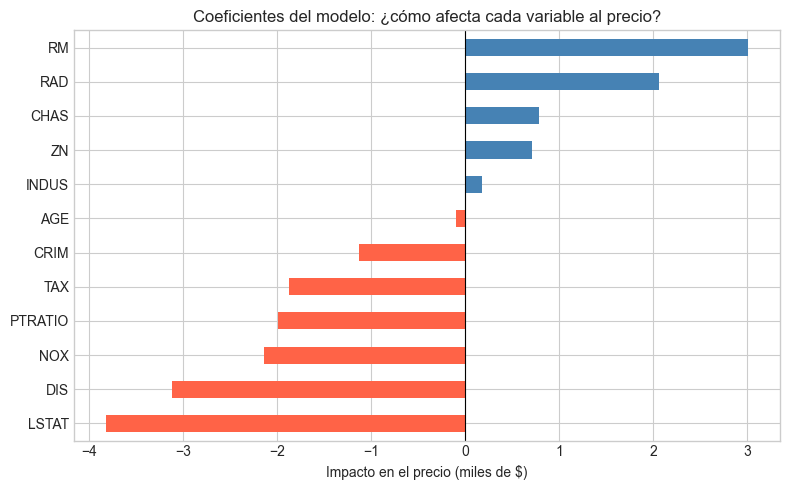

In [14]:
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_scaled, y_train)

print('✅ Modelo entrenado')

# Ver la importancia de cada variable (coeficientes)
coeficientes = pd.Series(modelo_lineal.coef_, index=X.columns).sort_values()

plt.figure(figsize=(8, 5))
coeficientes.plot(kind='barh', color=['tomato' if c < 0 else 'steelblue' for c in coeficientes])
plt.title('Coeficientes del modelo: ¿cómo afecta cada variable al precio?')
plt.xlabel('Impacto en el precio (miles de $)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

**Interpretación de los coeficientes:**
- **RM positivo**: más habitaciones → precio más alto (tiene sentido)
- **LSTAT negativo**: más pobreza en la zona → precio más bajo (tiene sentido)
- **NOX negativo**: más contaminación → precio más bajo (tiene sentido)


## 7. Evaluar el modelo
Usamos 4 métricas para ver qué tal predice:
- **MAE**: error medio en las mismas unidades que el precio (miles de $). Fácil de interpretar.
- **MSE**: error cuadrático medio. Penaliza más los errores grandes.
- **RMSE**: raíz del MSE. Vuelve a las mismas unidades que el precio.
- **R²**: porcentaje de variación del precio que explica el modelo. 1.0 = perfecto, 0 = no predice nada.


In [15]:
y_pred_lineal = modelo_lineal.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred_lineal)
mse  = mean_squared_error(y_test, y_pred_lineal)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_lineal)

print('=== Regresión Lineal ===')
print(f'MAE  = {mae:.2f}k$  → el modelo se equivoca de media {mae:.2f} miles de dólares')
print(f'MSE  = {mse:.2f}')
print(f'RMSE = {rmse:.2f}k$')
print(f'R²   = {r2:.3f}   → el modelo explica el {r2*100:.1f}% de la variación de precios')

=== Regresión Lineal ===
MAE  = 3.11k$  → el modelo se equivoca de media 3.11 miles de dólares
MSE  = 22.78
RMSE = 4.77k$
R²   = 0.689   → el modelo explica el 68.9% de la variación de precios


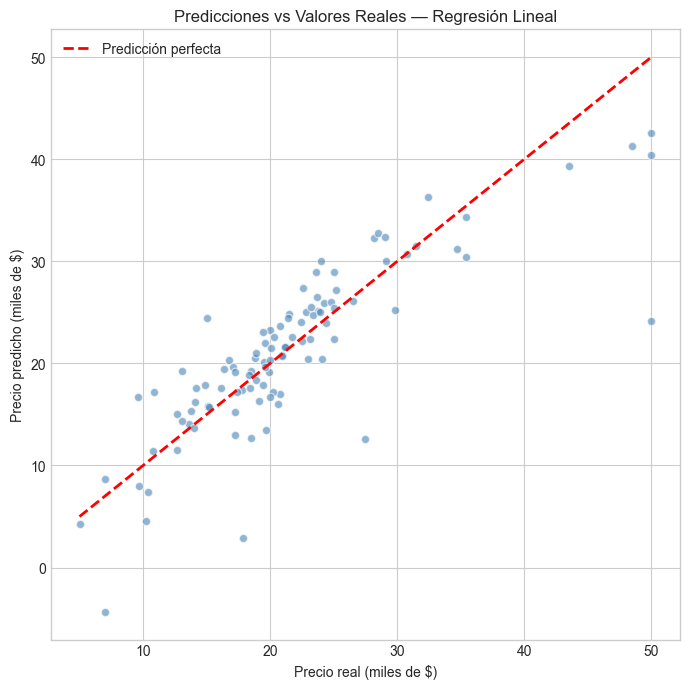

💡 Cuanto más cerca estén los puntos de la línea roja, mejor predice el modelo.


In [16]:
# Gráfico: predicciones vs valores reales
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_lineal, alpha=0.6, color='steelblue', edgecolors='white')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Predicción perfecta')
plt.xlabel('Precio real (miles de $)')
plt.ylabel('Precio predicho (miles de $)')
plt.title('Predicciones vs Valores Reales — Regresión Lineal')
plt.legend()
plt.tight_layout()
plt.show()

print('💡 Cuanto más cerca estén los puntos de la línea roja, mejor predice el modelo.')

**Interpretación:** Un R² de ~0.69 significa que el modelo explica el 69% de la variación de precios.
El error medio es de ~3k$ sobre precios que van de 5k$ a 50k$. Es un modelo decente pero mejorable.


## 8. Regularización: Ridge y Lasso
La regularización añade una 'penalización' a los coeficientes grandes para evitar el sobreajuste.

- **Ridge**: reduce los coeficientes pero no los elimina
- **Lasso**: puede poner algunos coeficientes a 0 (selección automática de variables)

El parámetro **alpha** controla cuánto penalizamos:
- Alpha pequeño (0.01) → poca regularización, parecido a regresión lineal normal
- Alpha grande (10) → mucha regularización, coeficientes más pequeños


### 8.1 Ridge

In [17]:
alphas = [0.1, 1.0, 10.0]
resultados_ridge = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    pred = ridge.predict(X_test_scaled)
    
    resultados_ridge.append({
        'alpha': alpha,
        'MAE':  round(mean_absolute_error(y_test, pred), 3),
        'MSE':  round(mean_squared_error(y_test, pred), 3),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, pred)), 3),
        'R2':   round(r2_score(y_test, pred), 3)
    })

df_ridge = pd.DataFrame(resultados_ridge).set_index('alpha')
print('=== Ridge ===')
print(df_ridge)

=== Ridge ===
         MAE     MSE   RMSE     R2
alpha                             
0.1    3.111  22.781  4.773  0.689
1.0    3.107  22.811  4.776  0.689
10.0   3.086  23.093  4.805  0.685


### 8.2 Lasso

In [18]:
alphas_lasso = [0.01, 0.1, 1.0]
resultados_lasso = []

for alpha in alphas_lasso:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_scaled, y_train)
    pred = lasso.predict(X_test_scaled)
    n_coef_cero = (lasso.coef_ == 0).sum()
    
    resultados_lasso.append({
        'alpha': alpha,
        'MAE':  round(mean_absolute_error(y_test, pred), 3),
        'MSE':  round(mean_squared_error(y_test, pred), 3),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, pred)), 3),
        'R2':   round(r2_score(y_test, pred), 3),
        'Variables eliminadas': n_coef_cero
    })

df_lasso = pd.DataFrame(resultados_lasso).set_index('alpha')
print('=== Lasso ===')
print(df_lasso)

=== Lasso ===
         MAE     MSE   RMSE     R2  Variables eliminadas
alpha                                                   
0.01   3.105  22.854  4.781  0.688                     0
0.10   3.168  24.414  4.941  0.667                     2
1.00   3.459  27.354  5.230  0.627                     7


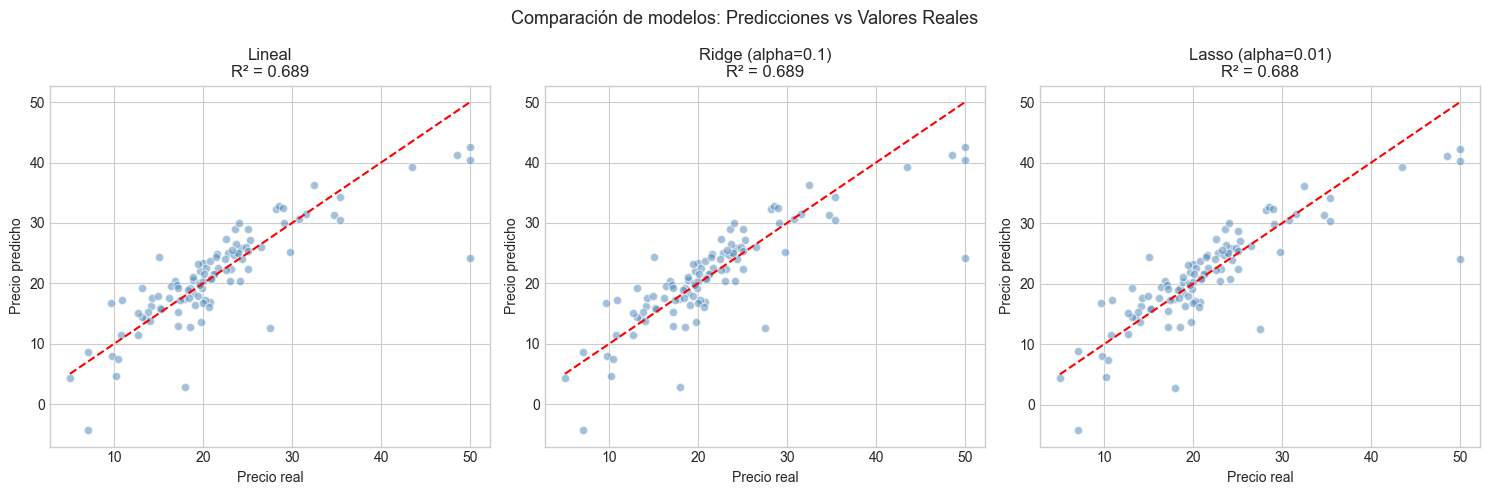

In [19]:
# Comparar los 3 mejores modelos visualmente
modelos_comparados = [
    ('Lineal', modelo_lineal, X_test_scaled),
    ('Ridge (alpha=0.1)', Ridge(alpha=0.1).fit(X_train_scaled, y_train), X_test_scaled),
    ('Lasso (alpha=0.01)', Lasso(alpha=0.01).fit(X_train_scaled, y_train), X_test_scaled)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (nombre, modelo, X_t) in zip(axes, modelos_comparados):
    pred = modelo.predict(X_t)
    r2_val = r2_score(y_test, pred)
    ax.scatter(y_test, pred, alpha=0.5, color='steelblue', edgecolors='white')
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    ax.set_title(f'{nombre}\nR² = {r2_val:.3f}')
    ax.set_xlabel('Precio real')
    ax.set_ylabel('Precio predicho')

plt.suptitle('Comparación de modelos: Predicciones vs Valores Reales', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Conclusiones

| Modelo | R² | MAE |
|---|---|---|
| Regresión Lineal | ~0.689 | ~3.11k$ |
| Ridge alpha=0.1 | ~0.689 | ~3.11k$ |
| Lasso alpha=0.01 | ~0.688 | ~3.12k$ |

### ¿Con qué modelo nos quedamos?

**Me quedaría con Regresión Lineal simple o Ridge con alpha=0.1**, por estas razones:

1. **Los tres modelos dan resultados muy similares** → en este dataset, la regularización no mejora mucho
   porque probablemente no hay sobreajuste grave.

2. **Ridge es ligeramente preferible a Lasso** aquí porque todas las variables parecen aportar algo
   (Lasso elimina variables y en este caso las necesitamos todas).

3. **El modelo explica el ~69% de la variación del precio** con un error medio de ~3.1k$.
   No es perfecto, pero es un resultado sólido para un primer modelo sin ingeniería de features.

### ¿Cómo se podría mejorar?
- Probar transformaciones logarítmicas (MEDV tiene valores atípicos altos)
- Añadir variables derivadas (por ejemplo, CRIM² o interacciones entre variables)
- Probar modelos más potentes como Random Forest o Gradient Boosting
